# "THE PRICE IS RIGHT" Capstone Project

This week - build a model that predicts how much something costs from a description, based on a scrape of Amazon data

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Evaluation, Baselines, Traditional ML  
DAY 4: Deep Learning and LLMs  
DAY 5: Fine-tuning a Frontier Model  

## DAY 3: Evaluation, Baselines, Traditional ML

Today we'll write some simple models to predict the price of a product

We'll use an approach to evaluate the performance of the model

And we'll test some Baseline Models using Traditional machine learning

In [ ]:
import random
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestRegressor
from pricer.evaluator import evaluate
from pricer.items import Item

In [ ]:
LITE_MODE = False

In [ ]:
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

In [ ]:
def random_pricer(item):
    return random.randrange(1,1000)

1: Guess: $655.00 Truth: $374.41 Error: $280.59 SLE: 0.31 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $115.00 Truth: $225.11 Error: $110.11 SLE: 0.45 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $26.00 Truth: $61.68 Error: $35.68 SLE: 0.71 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $760.00 Truth: $599.99 Error: $160.01 SLE: 0.06 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $282.00 Truth: $16.99 Error: $265.01 SLE: 7.59 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $251.00 Truth: $31.99 Error: $219.01 SLE: 4.13 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $229.00 Truth: $101.79 Error: $127.21 SLE: 0.65 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $143.00 Truth: $289.00 Error: $146.00 SLE: 0.49 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $755.00 Truth: $635.86 Error: $119.14 SLE: 0.03 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $105.00 Truth: $65.99 Error: $39.01 S

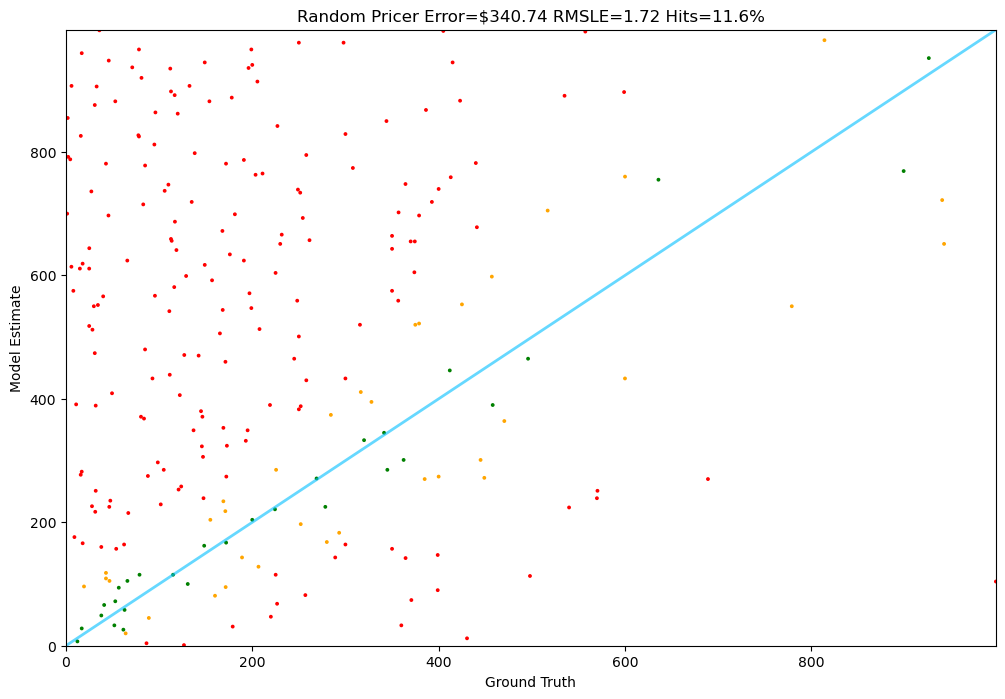

In [ ]:
random.seed(42)
evaluate(random_pricer, test)

In [ ]:
# That was fun!
# We can do better - here's another rather trivial model

training_prices = [item.price for item in train]
training_average = sum(training_prices) / len(training_prices)
print(training_average)

def constant_pricer(item):
    return training_average

1: Guess: $220.46 Truth: $374.41 Error: $153.95 SLE: 0.28 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $220.46 Truth: $225.11 Error: $4.65 SLE: 0.00 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $220.46 Truth: $61.68 Error: $158.78 SLE: 1.59 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $220.46 Truth: $599.99 Error: $379.53 SLE: 1.00 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $220.46 Truth: $16.99 Error: $203.47 SLE: 6.30 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $220.46 Truth: $31.99 Error: $188.47 SLE: 3.63 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $220.46 Truth: $101.79 Error: $118.67 SLE: 0.59 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $220.46 Truth: $289.00 Error: $68.54 SLE: 0.07 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $220.46 Truth: $635.86 Error: $415.40 SLE: 1.12 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $220.46 Truth: $65.99 Error: $154.47 S

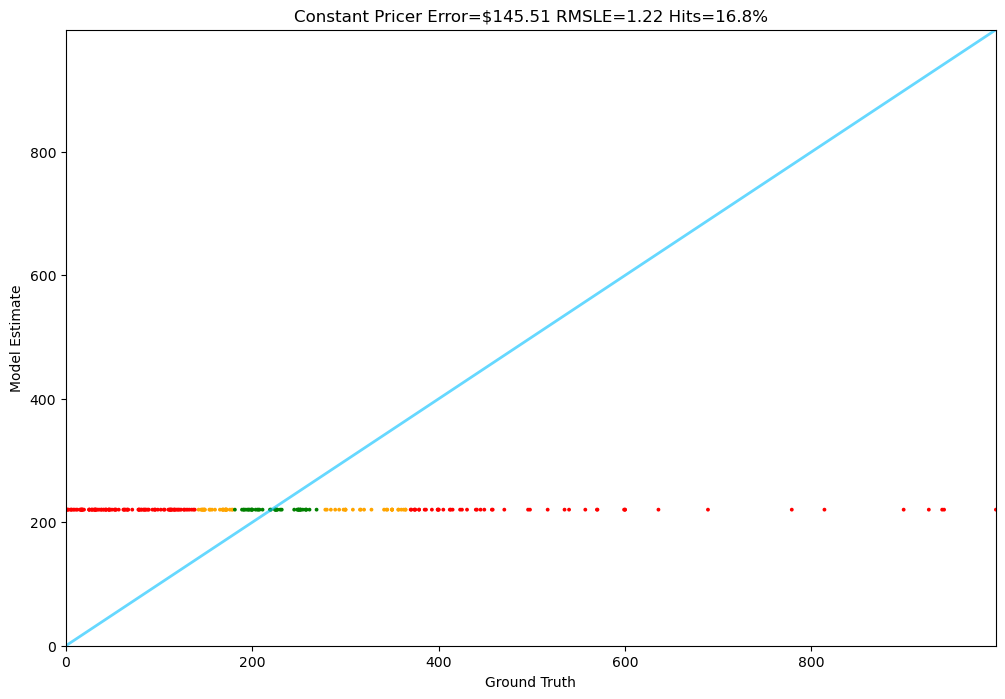

In [ ]:
evaluate(constant_pricer, test)

In [ ]:
def get_features(item):
    return {
        "weight": item.weight,
        "weight_unknown": 1 if item.weight==0 else 0,
        "text_length": len(item.summary)
    }

In [ ]:
def list_to_dataframe(items):
    features = [get_features(item) for item in items]
    df = pd.DataFrame(features)
    df['price'] = [item.price for item in items]
    return df

train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test)

{'weight': 1.1,
 'rank': 253009.0,
 'text_length': 729,
 'is_top_electronics_brand': 0}

In [ ]:
# Traditional Linear Regression!

np.random.seed(42)

# Separate features and target
feature_columns = ['weight', 'weight_unknown', 'text_length']

X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']

# Train a Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
print(f"Intercept: {model.intercept_}")

# Predict the test set and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

weight: 0.2642321862957332
rank: 5.197480233116737e-05
text_length: 0.0076093283513202605
is_top_electronics_brand: 198.14254283206898
Intercept: 182.18661987897428
Mean Squared Error: 33034.336771967995
R-squared Score: 0.09091571194865222


In [ ]:
def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]

1: Guess: $228.68 Truth: $374.41 Error: $145.73 SLE: 0.24 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $214.45 Truth: $225.11 Error: $10.66 SLE: 0.00 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $191.46 Truth: $61.68 Error: $129.78 SLE: 1.26 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $389.92 Truth: $599.99 Error: $210.07 SLE: 0.18 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $211.35 Truth: $16.99 Error: $194.36 SLE: 6.09 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $211.42 Truth: $31.99 Error: $179.43 SLE: 3.47 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $190.88 Truth: $101.79 Error: $89.09 SLE: 0.39 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $190.14 Truth: $289.00 Error: $98.86 SLE: 0.17 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $220.89 Truth: $635.86 Error: $414.97 SLE: 1.11 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $199.88 Truth: $65.99 Error: $133.89 S

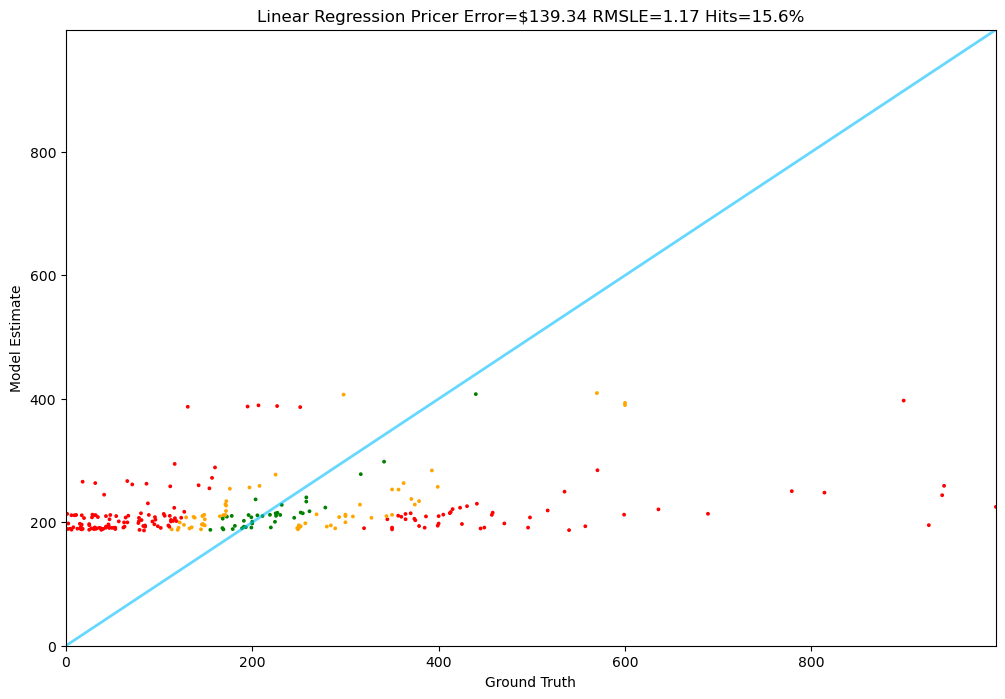

In [ ]:
evaluate(linear_regression_pricer, test)

Till now we used features to train our model, which didnt return expected results. Now we create a document of test_prompts and price to train

In [ ]:
prices = np.array([float(item.price) for item in train])
documents = [item.summary for item in train]

In [ ]:
np.random.seed(42)
vectorizer = CountVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(documents)


LinearRegression()

In [ ]:
# Here are the 1,000 most common words that it picked, not including "stop words":

selected_words = vectorizer.get_feature_names_out()
print(f"Number of selected words: {len(selected_words)}")
print("Selected words:", selected_words[1000:1020])

In [ ]:
regressor = LinearRegression()
regressor.fit(X, prices)

CountVectorizer is used to build the vocabulary of the top 1000 frequently used words. Basically If the vocabulary is ["apple", "banana", "cherry"] and a document is "apple banana apple", the vector would be [2, 1, 0] (2 occurrences of "apple", 1 of "banana", and 0 of "cherry").
##### Model Training
The resulting matrix (X) is a sparse matrix where rows represent documents and columns represent word counts.
This matrix is used as input features to train a LinearRegression model, with the target being the prices array (the price of each item).
##### Prediction
For a new item, its test_prompt() is transformed into a BoW vector using the same vocabulary.
The trained regression model predicts the price based on the BoW vector.

When testing with the document "apple banana cherry", it is also converted into a BoW vector using the same vocabulary. For example, the vector would be [1, 1, 1] (1 occurrence each of "apple", "banana", and "cherry").
The trained regression model uses this vector to predict the price. It applies the weights it learned during training to the word counts in the vector and outputs a predicted price.

In [ ]:
def natural_language_linear_regression_pricer(item):
    x = vectorizer.transform([item.summary])
    return max(regressor.predict(x)[0], 0)

1: Guess: $296.58 Truth: $374.41 Error: $77.83 SLE: 0.05 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $165.15 Truth: $225.11 Error: $59.96 SLE: 0.09 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $162.26 Truth: $61.68 Error: $100.58 SLE: 0.92 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $326.14 Truth: $599.99 Error: $273.85 SLE: 0.37 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $51.68 Truth: $16.99 Error: $34.69 SLE: 1.15 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $74.06 Truth: $31.99 Error: $42.07 SLE: 0.68 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $344.82 Truth: $101.79 Error: $243.03 SLE: 1.47 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $241.39 Truth: $289.00 Error: $47.61 SLE: 0.03 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $404.57 Truth: $635.86 Error: $231.29 SLE: 0.20 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $111.13 Truth: $65.99 Error: $45.14 SLE: 0

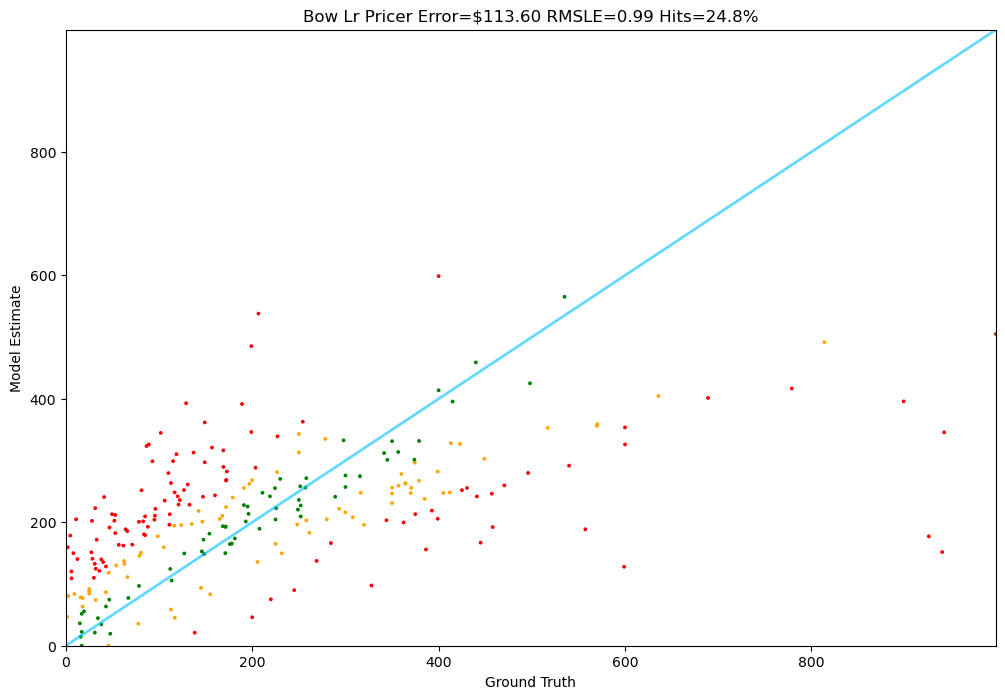

In [ ]:
evaluate(natural_language_linear_regression_pricer, test)

In [ ]:
subset = 15_000
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4)
rf_model.fit(X[:subset], prices[:subset])

## Random Forest model

The Random Forest is a type of "**ensemble**" algorithm, meaning that it combines many smaller algorithms to make better predictions.

It uses a very simple kind of machine learning algorithm called a **decision tree**. A decision tree makes predictions by examining the values of features in the input. Like a flow chart with IF statements. Decision trees are very quick and simple, but they tend to overfit.

In our case, the "features" are the elements of the Vector - in other words, it's the number of times that a particular word appears in the product description.

So you can think of it something like this:

**Decision Tree**  
\- IF the word "TV" appears more than 3 times THEN  
-- IF the word "LED" appears more than 2 times THEN  
--- IF the word "HD" appears at least once THEN  
---- Price = $500


With Random Forest, multiple decision trees are created. Each one is trained with a different random subset of the data, and a different random subset of the features. You can see above that we specify 100 trees, which is the default.

Then the Random Forest model simply takes the average of all its trees to product the final result.

In [ ]:
def random_forest(item):
    x = vectorizer.transform([item.summary])
    return max(0, rf_model.predict(x)[0])

In [ ]:
evaluate(random_forest, test)

In [ ]:
# This is how to save the model if you want to, particularly if you run this on a larger dataset

# import joblib
# joblib.dump(rf_model, "random_forest.joblib")

## Introducing XGBoost

Like Random Forest, XGBoost is also an ensemble model that combines multiple decision trees.

But unlike Random Forest, XGBoost builds one tree after another, with each next tree correcting for errors in the prior trees, using 'gradient descent'.

It's much faster than Random Forest, so we can run it for the full dataset, and it's typically better at generalizing.

**If this import doesn't work, please skip this! It's not required. On a Mac, you might need to do `brew install libomp` in the terminal.**

In [ ]:
import xgboost as xgb

In [ ]:
np.random.seed(42)

xgb_model = xgb.XGBRegressor(n_estimators=1000, random_state=42, n_jobs=4, learning_rate=0.1)
xgb_model.fit(X, prices)

In [ ]:
def xg_boost(item):
    x = vectorizer.transform([item.summary])
    return max(0, xgb_model.predict(x)[0])

In [ ]:
evaluate(xg_boost, test)

LinearRegression()

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/business.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#181;">Business applications</h2>
            <span style="color:#181;">Traditional ML isn't just useful for learning the history; it's still heavily used in industry today, particularly for tasks where there are clearly identifiable features. It's worth spending time exploring the algorithms and experimenting here. See if you can beat my numbers with Traditional ML! I ran the Random Forest for the entire 800,000 training dataset. It took about 15 hours to run, and it ended up getting a low error of $56.40. Traditional ML can do well - try it for yourself.</span>
        </td>
    </tr>
</table>